# Atividade Capítulo 10 - Análise de Produtos Agrícolas

Neste notebook nós fizemos a análise da base `produtos_agricolas.csv`, que traz informações de solo e clima para diferentes culturas agrícolas.

A ideia do trabalho foi entender melhor os dados, comparar o perfil das plantações e depois testar modelos de Machine Learning para prever qual cultura faz mais sentido para determinadas condições de solo e clima.

Procuramos manter uma linguagem mais direta, explicando o que foi feito e o que conseguimos observar nos gráficos, sem deixar o relatório técnico demais.

## 0. Instalação das dependências

Antes de começar, vamos instalar as bibliotecas necessárias para executar este notebook. Basta executar a célula abaixo.

In [1]:
!pip install pandas seaborn matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 384.5 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 8.5 MB/s eta 0:00:00
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 11.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 10.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 10.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 7.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Carregando as bibliotecas e os dados

Primeiro carregamos as bibliotecas que serão usadas no notebook. Também fizemos a leitura do arquivo CSV e mostramos as primeiras linhas da base para conferir se os dados foram carregados corretamente.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# Carregando o dataset
# Importante: o arquivo CSV precisa estar na mesma pasta deste notebook.
df = pd.read_csv('produtos_agricolas.csv')

# Primeiras linhas da base
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Dicionário de tradução das culturas

Como a base original está com os nomes das culturas em inglês, criamos um dicionário para traduzir esses nomes para português. Fizemos isso porque facilita a leitura dos gráficos e também deixa o trabalho mais claro para apresentação.

In [3]:
# Dicionário para traduzir as culturas do inglês para o português
traducao_culturas = {
    'rice': 'Arroz',
    'maize': 'Milho',
    'chickpea': 'Grão-de-bico',
    'kidneybeans': 'Feijão-vermelho',
    'pigeonpeas': 'Feijão-guandu',
    'mothbeans': 'Feijão-moth',
    'mungbean': 'Feijão-mungo',
    'blackgram': 'Feijão-preto',
    'lentil': 'Lentilha',
    'pomegranate': 'Romã',
    'banana': 'Banana',
    'mango': 'Manga',
    'grapes': 'Uva',
    'watermelon': 'Melancia',
    'muskmelon': 'Melão',
    'apple': 'Maçã',
    'orange': 'Laranja',
    'papaya': 'Mamão',
    'coconut': 'Coco',
    'cotton': 'Algodão',
    'jute': 'Juta',
    'coffee': 'Café'
}

# Criando uma nova coluna com a cultura traduzida
df['cultura'] = df['label'].map(traducao_culturas)

# Conferindo se todas foram traduzidas corretamente
df[['label', 'cultura']].drop_duplicates().sort_values('cultura').reset_index(drop=True)

,label,cultura
0,cotton,Algodão
1,rice,Arroz
2,banana,Banana
3,coffee,Café
4,coconut,Coco
5,pigeonpeas,Feijão-guandu
6,mothbeans,Feijão-moth
7,mungbean,Feijão-mungo
8,blackgram,Feijão-preto
9,kidneybeans,Feijão-vermelho


## 3. Análise exploratória inicial

Nesta parte nós conferimos o tamanho da base, os tipos de dados, se existem valores vazios e também as estatísticas gerais. Essa etapa é importante porque antes de criar gráficos ou modelos é preciso entender se a base está organizada.

In [4]:
print('Quantidade de linhas e colunas:', df.shape)
print('Informações da base:')
df.info()

print('Quantidade de valores ausentes por coluna:')
print(df.isnull().sum())

df.describe()

Quantidade de linhas e colunas: (2200, 9)
Informações da base:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
 8   cultura      2200 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 154.8 KB
Quantidade de valores ausentes por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
cultura        0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### Análise inicial

A base possui variáveis numéricas relacionadas ao solo e ao clima, como nitrogênio, fósforo, potássio, temperatura, umidade, pH e chuva. A coluna `label` representa a cultura indicada para aquelas condições.

Um ponto positivo é que não encontramos valores vazios na base, então não foi necessário fazer tratamento para dados ausentes. Também observamos que as variáveis possuem escalas diferentes. Por exemplo, o pH trabalha em uma faixa menor, enquanto chuva, nitrogênio, fósforo e potássio possuem valores maiores. Por isso, usamos padronização dos dados na etapa de Machine Learning.

## 4. Análise descritiva com gráficos

Nesta etapa nós criamos os gráficos para entender melhor o comportamento das variáveis e a relação delas com as culturas agrícolas. A proposta aqui foi sair um pouco da tabela e visualizar os padrões de forma mais clara.

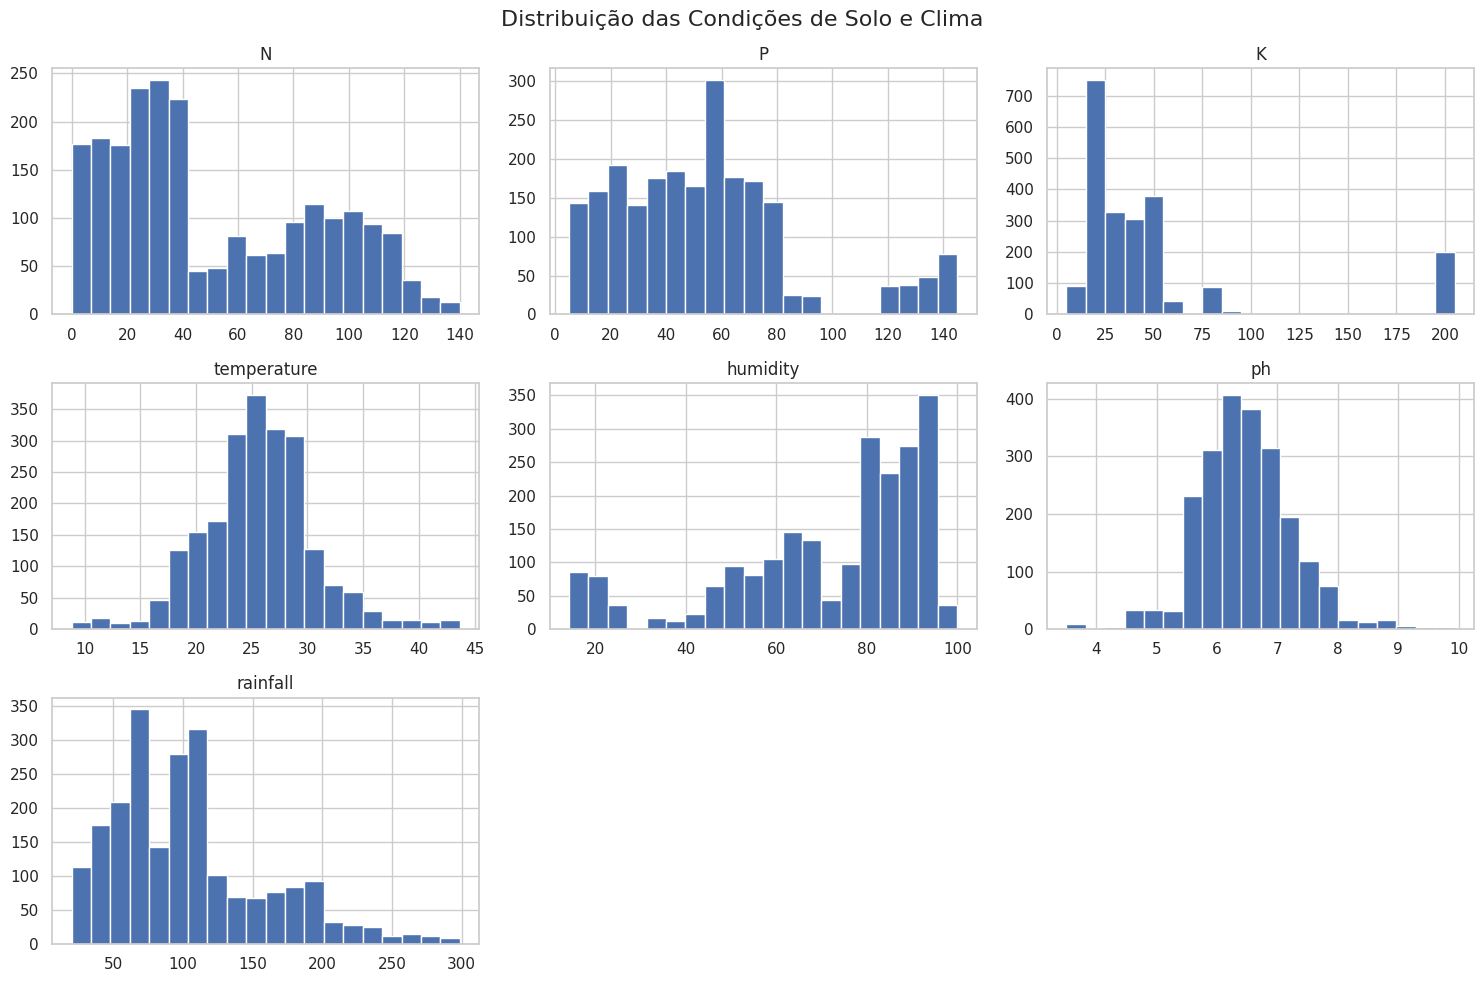

In [5]:
# Gráfico 1: Distribuição das variáveis numéricas
variaveis_numericas = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

df[variaveis_numericas].hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribuição das Condições de Solo e Clima', fontsize=16)
plt.tight_layout()
plt.show()

### Análise do Gráfico 1

Os histogramas mostram que cada variável possui um comportamento diferente. Algumas ficam mais concentradas em determinadas faixas, enquanto outras aparecem mais espalhadas.

Esse gráfico ajuda a entender a base de forma geral. Para nós, ele é importante porque mostra que não dá para tratar todas as variáveis como se tivessem a mesma escala ou o mesmo comportamento. Esse foi um dos motivos para usarmos o `StandardScaler` antes de treinar os modelos.

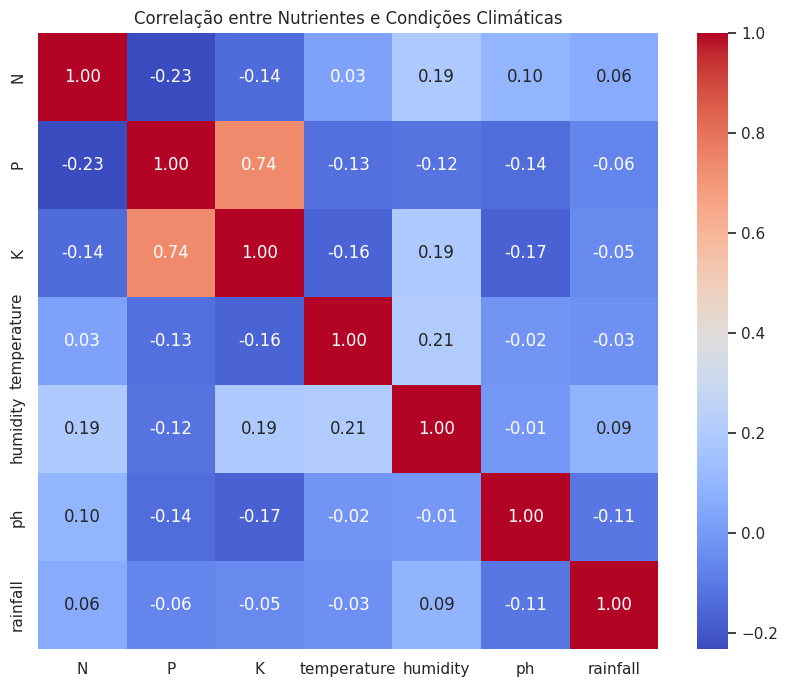

In [6]:
# Gráfico 2: Matriz de correlação entre as variáveis numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Nutrientes e Condições Climáticas')
plt.show()

### Análise do Gráfico 2

A matriz de correlação mostra se existe relação linear entre as variáveis. De forma geral, não aparecem correlações extremamente fortes entre todas as variáveis, o que indica que cada uma pode contribuir de um jeito diferente para identificar a cultura.

Mesmo quando a correlação não é alta, isso não significa que a variável não seja útil. Muitas vezes a cultura é definida pela combinação das condições de solo e clima, e não por uma variável isolada.

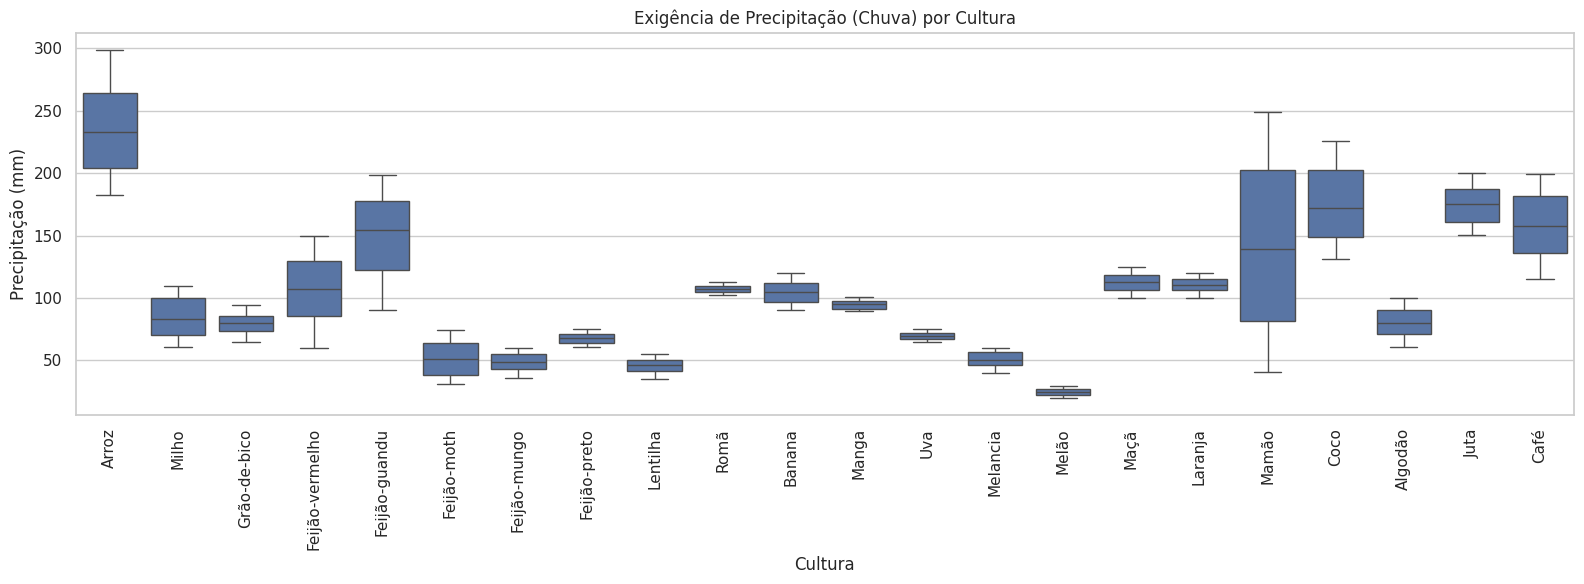

In [7]:
# Gráfico 3: Precipitação por cultura
plt.figure(figsize=(16, 6))
sns.boxplot(x='cultura', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.title('Exigência de Precipitação (Chuva) por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Precipitação (mm)')
plt.tight_layout()
plt.show()

### Análise do Gráfico 3

O boxplot de chuva foi um dos gráficos que achamos mais relevantes, porque a precipitação tem relação direta com o desenvolvimento das plantações.

É possível perceber que algumas culturas aparecem associadas a volumes maiores de chuva, enquanto outras ficam em faixas menores. O arroz, por exemplo, aparece com uma necessidade maior de precipitação. Já a uva apresenta um perfil com menor dependência de chuva quando comparada com algumas outras culturas.

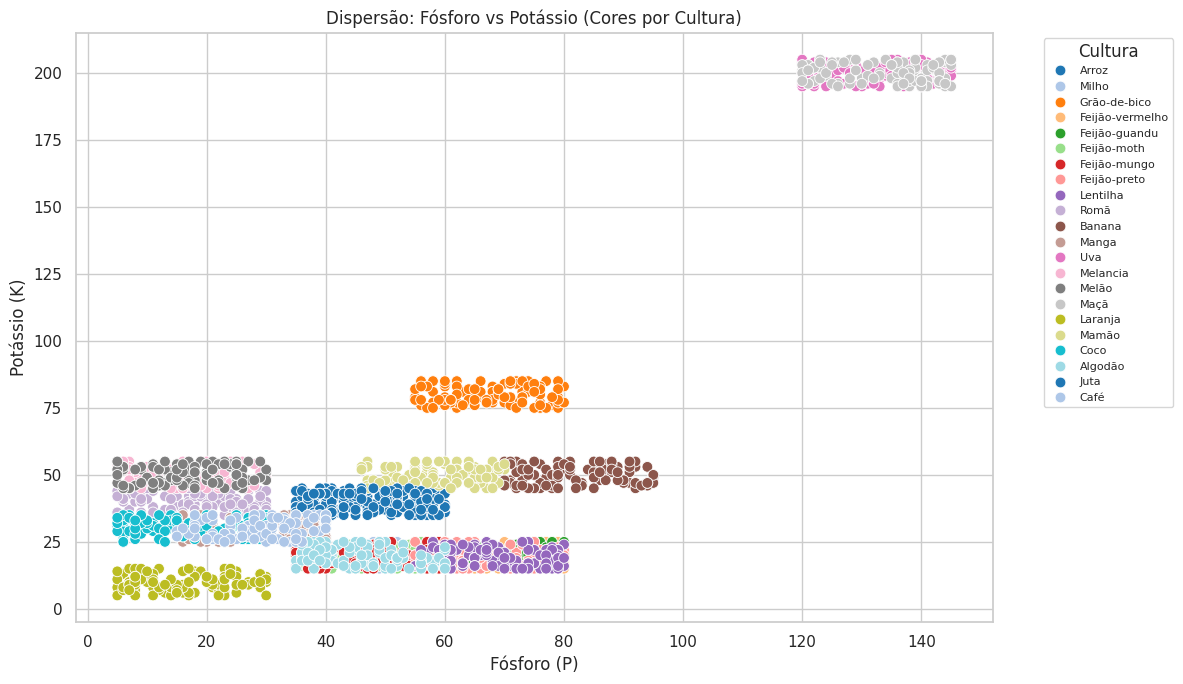

In [8]:
# Gráfico 4: Relação entre Fósforo e Potássio com cores por cultura
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='P',
    y='K',
    hue='cultura',
    palette='tab20',
    s=60
)
plt.title('Dispersão: Fósforo vs Potássio (Cores por Cultura)')
plt.xlabel('Fósforo (P)')
plt.ylabel('Potássio (K)')

# Legenda fora do gráfico para não estourar a área de plotagem
plt.legend(title='Cultura', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

### Análise do Gráfico 4

Neste gráfico comparamos fósforo e potássio, usando cores para separar as culturas. Ele ajuda bastante porque algumas plantações ficam agrupadas em regiões específicas.

Isso indica que certas culturas possuem exigências diferentes de nutrientes. Esse tipo de separação visual também ajuda a explicar por que os modelos de Machine Learning conseguiram bons resultados, já que existem padrões nos dados que facilitam a classificação.

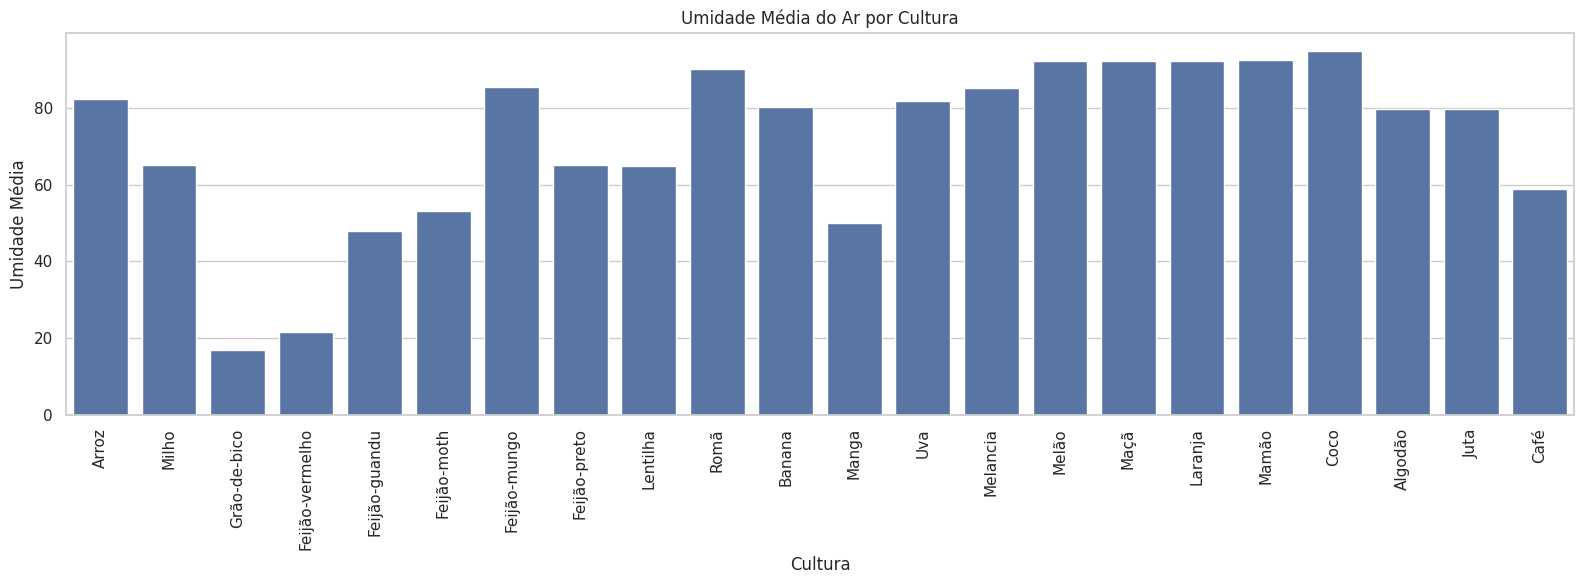

In [9]:
# Gráfico 5: Umidade média por cultura
plt.figure(figsize=(16, 6))
sns.barplot(x='cultura', y='humidity', data=df, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Umidade Média do Ar por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Umidade Média')
plt.tight_layout()
plt.show()

### Análise do Gráfico 5

O gráfico de umidade média mostra que algumas culturas estão mais ligadas a ambientes úmidos, enquanto outras aparecem em condições com menor umidade.

Essa análise fica mais forte quando olhamos junto com chuva e temperatura, porque a cultura não depende de uma única variável. O ideal é olhar o conjunto das condições climáticas e do solo.

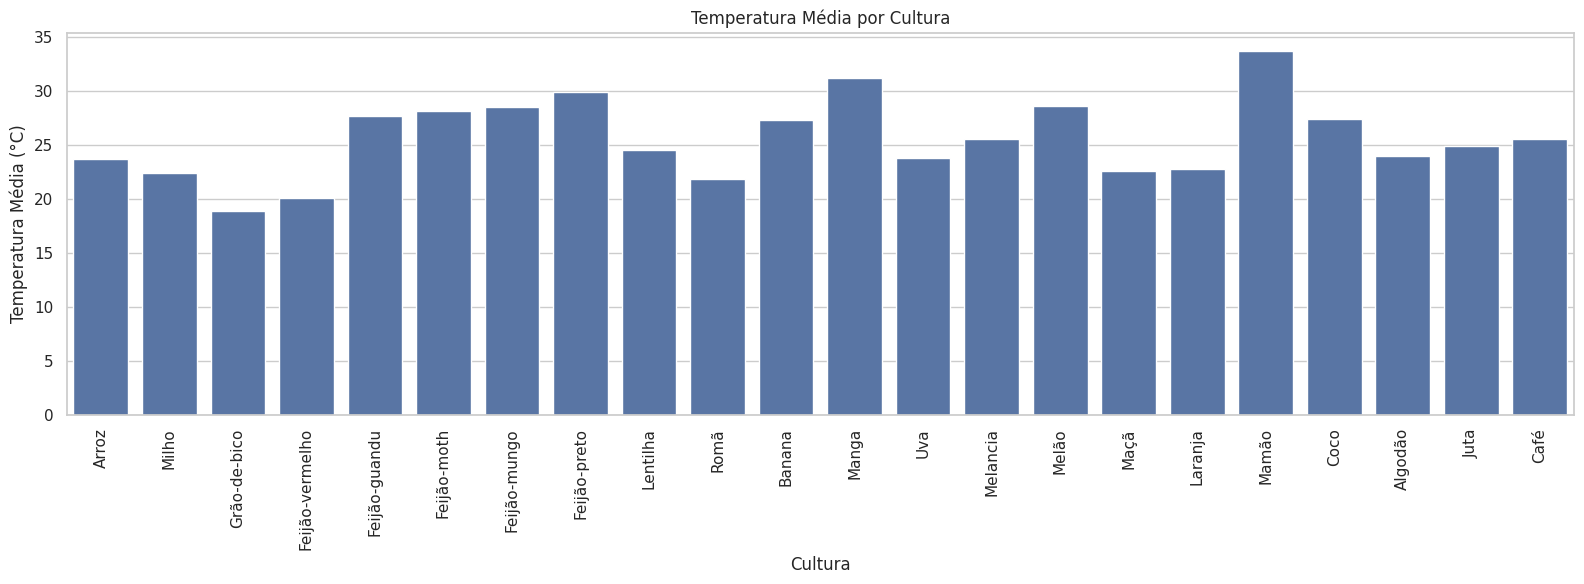

In [10]:
# Gráfico 6: Temperatura média por cultura
plt.figure(figsize=(16, 6))
sns.barplot(x='cultura', y='temperature', data=df, estimator='mean', errorbar=None)
plt.xticks(rotation=90)
plt.title('Temperatura Média por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Temperatura Média (°C)')
plt.tight_layout()
plt.show()

### Análise do Gráfico 6

A temperatura média por cultura ajuda a identificar quais plantações estão mais associadas a temperaturas mais altas ou mais moderadas.

Esse gráfico complementa os anteriores, principalmente a análise de chuva e umidade. Com isso, fica mais fácil montar o perfil de cada cultura e comparar quais condições favorecem cada plantação.

## 5. Perfil ideal de solo e clima

Para encontrar o perfil ideal, calculamos a média das variáveis para cada cultura. Essa média não significa que só exista um valor correto para plantio, mas ajuda a representar o comportamento típico de cada cultura dentro da base.

Escolhemos comparar **Arroz**, **Café** e **Uva**, porque elas possuem perfis bem diferentes e isso facilita a análise.

In [11]:
# Média geral da base
media_geral = df[variaveis_numericas].mean()

# Perfil médio por cultura
perfis = df.groupby('cultura')[variaveis_numericas].mean().round(2)

# Comparativo com três culturas escolhidas
culturas_escolhidas = ['Arroz', 'Café', 'Uva']
comparativo = perfis.loc[culturas_escolhidas]

print('Média geral da base:')
display(media_geral.round(2).to_frame('Média Geral'))

print('Perfil médio das culturas escolhidas:')
display(comparativo)

Média geral da base:


,Média Geral
N,50.55
P,53.36
K,48.15
temperature,25.62
humidity,71.48
ph,6.47
rainfall,103.46


Perfil médio das culturas escolhidas:


,N,P,K,temperature,humidity,ph,rainfall
cultura,,,,,,,
Arroz,79.89,47.58,39.87,23.69,82.27,6.43,236.18
Café,101.20,28.74,29.94,25.54,58.87,6.79,158.07
Uva,23.18,132.53,200.11,23.85,81.88,6.03,69.61


### Análise do perfil ideal

Com as médias por cultura, fica claro que cada plantação possui um perfil próprio de solo e clima.

O **Arroz** aparece com maior necessidade de chuva e também com umidade elevada. Isso indica um perfil mais úmido, o que faz sentido quando pensamos em uma cultura que normalmente depende bastante de água.

O **Café** apresenta destaque em nitrogênio e também uma boa necessidade de chuva. Dentro da base, ele fica associado a um solo com maior presença de nitrogênio e um ambiente com boa disponibilidade hídrica.

A **Uva** chama atenção pelos valores mais altos de fósforo e potássio, mas com menor precipitação quando comparada ao arroz e ao café. Ou seja, ela parece depender mais de um perfil específico de nutrientes do solo do que de muita chuva.

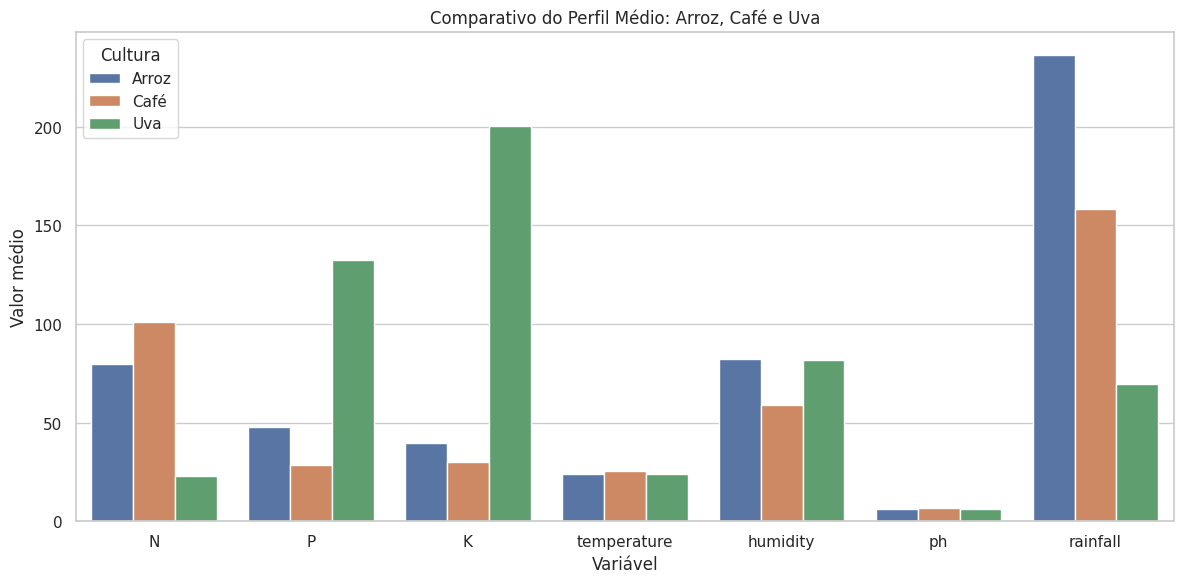

In [12]:
# Gráfico comparativo das três culturas escolhidas
comparativo_plot = comparativo.reset_index().melt(id_vars='cultura', var_name='Variável', value_name='Média')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparativo_plot, x='Variável', y='Média', hue='cultura')
plt.title('Comparativo do Perfil Médio: Arroz, Café e Uva')
plt.xlabel('Variável')
plt.ylabel('Valor médio')
plt.legend(title='Cultura')
plt.tight_layout()
plt.show()

## 6. Desenvolvimento dos modelos preditivos

Nesta etapa nós criamos cinco modelos de Machine Learning, cada um usando um algoritmo diferente. O objetivo foi prever a cultura agrícola mais indicada com base nas condições de solo e clima.

Os modelos testados foram:

- Regressão Logística;
- KNN;
- Árvore de Decisão;
- Random Forest;
- SVM.

Como algumas variáveis possuem escalas bem diferentes, aplicamos o `StandardScaler`. Também usamos `random_state=42` nos modelos que possuem aleatoriedade, para facilitar a reprodução dos resultados.

In [13]:
# Preparação dos dados
X = df.drop(['label', 'cultura'], axis=1)
y = df['cultura']  # usando os nomes em português para deixar os resultados mais claros

# Divisão treino/teste
# O stratify=y mantém a proporção das culturas no treino e no teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definição dos 5 algoritmos
# O random_state ajuda a manter os resultados reproduzíveis nos modelos que possuem aleatoriedade.
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Treinamento e avaliação
resultados = []
predicoes_modelos = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    predicoes = modelo.predict(X_test_scaled)
    predicoes_modelos[nome] = predicoes
    
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, predicoes),
        'Precisão': precision_score(y_test, predicoes, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predicoes, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, predicoes, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='Acurácia', ascending=False)
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
3,Random Forest,0.997727,0.997835,0.997727,0.997726
2,Árvore de Decisão,0.995455,0.995671,0.995455,0.995452
4,SVM,0.986364,0.987774,0.986364,0.986501
1,KNN,0.981818,0.983249,0.981818,0.981839
0,Regressão Logística,0.970455,0.971481,0.970455,0.970360


### Análise dos modelos

A tabela compara os cinco modelos usando acurácia, precisão, recall e F1-score. Como o problema possui várias culturas possíveis, essas métricas ajudam a avaliar melhor o desempenho dos algoritmos.

A **acurácia** mostra o percentual geral de acertos. Já o **F1-score** ajuda a analisar o equilíbrio entre precisão e recall.

De forma geral, os resultados foram bons. Isso indica que as variáveis de solo e clima possuem padrões suficientes para diferenciar as culturas. Os modelos baseados em árvore, principalmente o Random Forest, costumam se sair bem nesse tipo de problema porque conseguem trabalhar melhor com combinações e relações não lineares entre as variáveis.

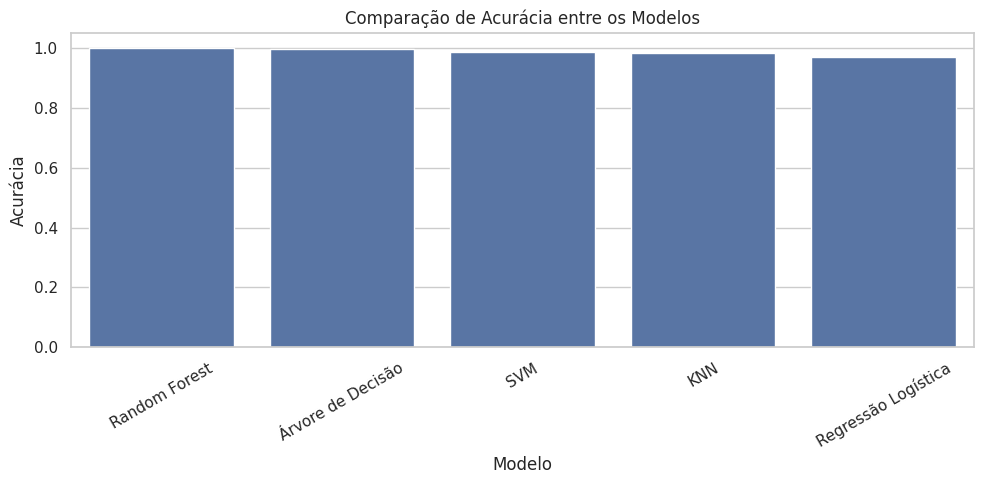

In [14]:
# Gráfico comparando a acurácia dos modelos
plt.figure(figsize=(10, 5))
sns.barplot(data=df_resultados, x='Modelo', y='Acurácia')
plt.title('Comparação de Acurácia entre os Modelos')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.ylabel('Acurácia')
plt.tight_layout()
plt.show()

In [15]:
# Relatório de classificação do melhor modelo
melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
melhor_predicao = predicoes_modelos[melhor_modelo_nome]

print('Melhor modelo:', melhor_modelo_nome)
print('Relatório de classificação:')
print(classification_report(y_test, melhor_predicao, zero_division=0))

Melhor modelo: Random Forest
Relatório de classificação:
                 precision    recall  f1-score   support

        Algodão       1.00      1.00      1.00        20
          Arroz       1.00      1.00      1.00        20
         Banana       1.00      1.00      1.00        20
           Café       1.00      1.00      1.00        20
           Coco       1.00      1.00      1.00        20
  Feijão-guandu       1.00      1.00      1.00        20
    Feijão-moth       1.00      0.95      0.97        20
   Feijão-mungo       1.00      1.00      1.00        20
   Feijão-preto       1.00      1.00      1.00        20
Feijão-vermelho       1.00      1.00      1.00        20
   Grão-de-bico       1.00      1.00      1.00        20
           Juta       1.00      1.00      1.00        20
        Laranja       1.00      1.00      1.00        20
       Lentilha       0.95      1.00      0.98        20
          Mamão       1.00      1.00      1.00        20
          Manga       1.00    

### Observação sobre a matriz de confusão

Nós optamos por não manter a matriz de confusão na versão final do notebook porque existem muitas culturas na base. Com isso, o gráfico fica muito carregado visualmente e acaba não ajudando tanto na leitura.

Para este trabalho, a comparação por tabela de métricas e o gráfico de acurácia já atendem melhor ao objetivo de comparar os modelos de forma clara.

## 7. Conclusão

Com a análise exploratória, conseguimos perceber que as culturas agrícolas possuem perfis diferentes de solo e clima. Variáveis como chuva, umidade, fósforo, potássio e nitrogênio ajudam bastante a separar os tipos de plantação.

Na comparação entre arroz, café e uva, observamos que o arroz está mais ligado a maior precipitação e umidade. O café aparece com destaque em nitrogênio e chuva. Já a uva apresenta valores altos de fósforo e potássio, mas menor necessidade de precipitação.

Na parte de Machine Learning, os cinco modelos apresentaram bons resultados. A tabela de métricas permite comparar qual algoritmo teve melhor desempenho. Neste trabalho, a matriz de confusão não foi mantida na versão final porque, com muitas culturas, o visual ficou muito carregado e não ajudou tanto na interpretação. Para a entrega, a tabela de métricas e o gráfico de acurácia já deixam a comparação mais clara.

Como limitação, é importante lembrar que a base é bem organizada e controlada. Em uma situação real, poderiam existir dados faltantes, erros de medição, diferenças regionais e outros fatores que também influenciam o plantio. Como melhoria futura, seria interessante testar ajustes de hiperparâmetros, validar com mais dados reais e incluir variáveis como produtividade, tipo de solo e região.